In [2]:
import mdtraj as md
import nglview as nv
import numpy as np

import matplotlib.pyplot as plt

# Water in Water

In [3]:
version = "v2"
# folder = f"/Users/fleurdolmans/Documents/UvA/Master AI/Thesis/HDD/data/molecules/md/water/{version}"

folder = f"/Users/fleurdolmans/Downloads/md/water/pbc/{version}"
h5_path = f"{folder}/traj_waterInwater.h5"
traj = md.load_hdf5(h5_path)

# # Save pdb file. This file you can use in for example VDM if you would like to use another visualization software.
# traj.save(f"{folder}/traj_waterInwater_{version}.pdb") 


#### Basic Droplet Info

In [4]:
# Basic droplet info
print("Number of Frames:", traj.n_frames)
print("Total number of Atoms:", traj.n_atoms)
print("Number of residues:", traj.n_residues)

view = nv.show_mdtraj(traj)
view.clear_representations()

# solvent first: transparent
view.add_representation(
    "licorice",
    selection="all"
)

# solute water second: thick + red
view.add_representation(
    "ball+stick",
    selection="@0,1,2",
    colorValue="red",
    radius=0.2
)

view.center()
view



Number of Frames: 1000000
Total number of Atoms: 1569
Number of residues: 523


NGLWidget(max_frame=999999)

In [5]:
# Number of solvent and solute atoms in droplet
top = traj.topology

table, bonds = top.to_dataframe()
print(table.head())


  serial name element  resSeq resName  chainID segmentID  formal_charge
0   None    O       O       1     HOH        0                     <NA>
1   None   H1       H       1     HOH        0                     <NA>
2   None   H2       H       1     HOH        0                     <NA>
3   None    O       O       2     HOH        1                     <NA>
4   None   H1       H       2     HOH        1                     <NA>


In [6]:
a0 = list(top.atoms)[0]
print("Atom 0:", a0.index, a0.name, a0.element, a0.residue)

# sulfur atom index (pick the first one)
o_idx = a0.index
o_idx

# o_xyz = traj.xyz[:, o_idx, :]   # shape (n_frames, 3) in nm
# r = np.linalg.norm(o_xyz, axis=1)

# print("Oxygen distance from origin (nm):")
# print("mean", r.mean(), "std", r.std(), "max", r.max())


Atom 0: 0 O oxygen HOH1


0

In [7]:
solute = top.select("resid 0")                 # first water = solute
solvent = top.select("water and not resid 0")  # rest = solvent
solute_O = top.select("resid 0 and element O")


solvent_O = top.select("water and element O and not resid 0")

print("Number of atoms in solute:", solute.size)
print("Number of oxygen atoms in solute:", solute_O.size)
print("Number of atoms in solvent:", solvent.size)
print("Number of oxygen atoms in solvent:", solvent_O.size)


Number of atoms in solute: 3
Number of oxygen atoms in solute: 1
Number of atoms in solvent: 1566
Number of oxygen atoms in solvent: 522


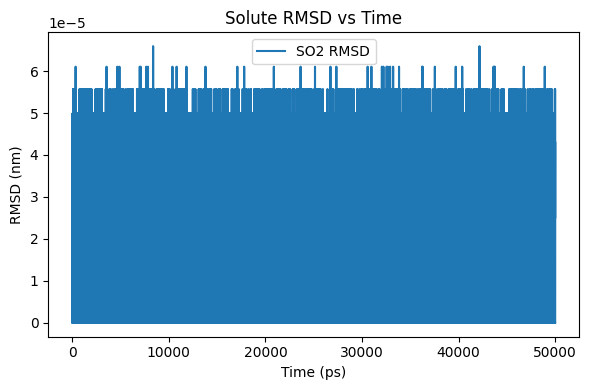

In [8]:
rmsd = md.rmsd(traj, traj, 0, atom_indices=solute)
rmsd_all = md.rmsd(traj, traj, 0)

dt_fs = 0.5      # your timestep
save_interval = 100  # frames saved every N steps
time_ps = np.arange(traj.n_frames) * dt_fs * save_interval / 1000

plt.figure(figsize=(6,4))
plt.plot(time_ps, rmsd, label="SO2 RMSD")
plt.xlabel("Time (ps)")
plt.ylabel("RMSD (nm)")
plt.title("Solute RMSD vs Time")
plt.legend()
plt.tight_layout()
plt.show()

## Radial distribution function


$g(r) = \frac{\langle \rho (r)\rangle }{\rho}=\frac{\text{local number of density at distance } r}{\text{bulk number desity}} $

### Solvation structure (S-O(water))
How close do the center of water molecules (solvent) approach the solute center?


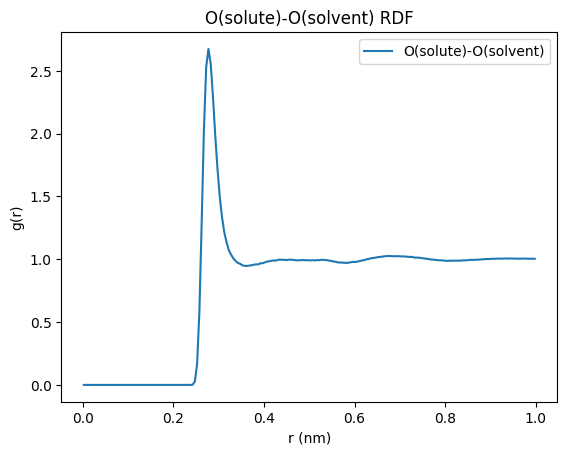

In [9]:
import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt

pairs = top.select_pairs(solute_O, solvent_O)
r, g_r = md.compute_rdf(traj, pairs=pairs, r_range=(0, 1.0), bin_width=0.005)

plt.plot(r, g_r, label="O(solute)-O(solvent)")
plt.title("O(solute)-O(solvent) RDF")
plt.xlabel("r (nm)")
plt.ylabel("g(r)")
plt.legend()
plt.show()

In [10]:
rho = len(solvent_O) / traj.unitcell_volumes.mean()  # number density
print("The average number of solvent (water) molecules per unit volume (number density) is:", rho, "nm^-3")

coord_number = 4 * np.pi * rho * np.trapz(g_r * r**2, r)
print("Coordination number:", coord_number)

The average number of solvent (water) molecules per unit volume (number density) is: 33.408 nm^-3
Coordination number: 138.25259765998962


/var/folders/tx/zbry1_2j2_57jk0nsqv4m9080000gn/T/ipykernel_52027/3199095728.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  coord_number = 4 * np.pi * rho * np.trapz(g_r * r**2, r)


### Solvent Leakage

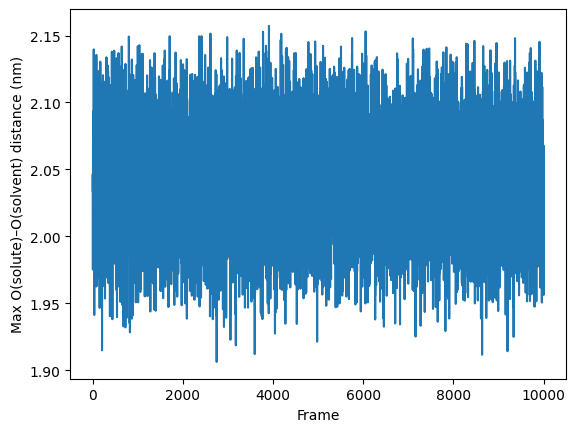

In [10]:
solute_O = top.select("resid 0 and element O")                 # 1 oxygen atom

pairs = top.select_pairs(solute_O, solvent_O)   # (n_solvent_waters, 2)
d = md.compute_distances(traj, pairs)           # shape (n_frames, n_solvent_waters)

max_dist_per_frame = d.max(axis=1)

plt.plot(max_dist_per_frame)
plt.xlabel("Frame")
plt.ylabel("Max O(solute)–O(solvent) distance (nm)")
plt.show()


# SO2 in Water

In [6]:
version = "v2"
folder = f"/Users/fleurdolmans/Downloads/md/so2/pbc/{version}"
h5_path = f"{folder}/traj_so2Inwater.h5"
traj = md.load_hdf5(h5_path)

# Save pdb file. This file you can use in for example VDM if you would like to use another visualization software.
# traj.save(f"{folder}/traj_so2Inwater_{version}.pdb")

#### Basic Droplet Info

In [7]:
# Basic droplet info
print("Number of Frames:", traj.n_frames)
print("Total number of Atoms:", traj.n_atoms)
print("Number of residues:", traj.n_residues)

view = nv.show_mdtraj(traj)
view.clear_representations()
# view.add_representation("ball+stick", selection="all")   # show all atoms
view.center()


# solvent
view.add_representation(
    "licorice",
    selection="all"
)

# solute 
view.add_representation(
    "ball+stick",
    selection="@0,1,2",
    radius=0.2
)

view

Number of Frames: 10000
Total number of Atoms: 1569
Number of residues: 523


NGLWidget(max_frame=9999)

In [22]:
# Number of solvent and solute atoms in droplet
top = traj.topology

table, bonds = top.to_dataframe()
print(table.head())


  serial name element  resSeq resName  chainID segmentID  formal_charge
0   None    S       S       1     SO2        0                     <NA>
1   None   O1       O       1     SO2        0                     <NA>
2   None   O2       O       1     SO2        0                     <NA>
3   None    O       O       2     HOH        1                     <NA>
4   None   H1       H       2     HOH        1                     <NA>


In [23]:
first_atoms = list(top.atoms)[:10]
for a in first_atoms:
    print(a.index, a.name, a.element, a.residue)

0 S sulfur SO21
1 O1 oxygen SO21
2 O2 oxygen SO21
3 O oxygen HOH2
4 H1 hydrogen HOH2
5 H2 hydrogen HOH2
6 O oxygen HOH3
7 H1 hydrogen HOH3
8 H2 hydrogen HOH3
9 O oxygen HOH4


In [24]:
a0 = list(top.atoms)[0]
print("Atom 0:", a0.index, a0.name, a0.element, a0.residue)


Atom 0: 0 S sulfur SO21


In [25]:
import numpy as np

a0 = list(top.atoms)[0]
print("Atom 0:", a0.index, a0.name, a0.element, a0.residue)

# sulfur atom index (pick the first one)
s_idx = a0.index
s_idx

s_xyz = traj.xyz[:, s_idx, :]   # shape (n_frames, 3) in nm
r = np.linalg.norm(s_xyz, axis=1)

print("Sulfur distance from origin (nm):")
print("mean", r.mean(), "std", r.std(), "max", r.max())

Atom 0: 0 S sulfur SO21
Sulfur distance from origin (nm):
mean 2.9206657 std 0.8378994 max 5.2523985


In [26]:

# traj = md.load_pdb("/Users/fleurdolmans/Documents/UvA/Master AI/Thesis/HDD/data/molecules/solutes/so2.pdb")
top = traj.topology

# for bond in top.bonds:
#     i = bond.atom1.index
#     j = bond.atom2.index
#     r = md.compute_distances(traj, [[i, j]])[0][0] * 10  # nm → Å
#     print(bond.atom1.name, bond.atom2.name, r, "Å")


In [27]:
solute = top.select("not water")
solute_S = top.select("element S")

solvent = top.select("water")
solvent_O = top.select("water and element O")

print("Number of atoms in solute:", solute.size)
print("Number of atoms in solute sulfur:", solute_S.size)
print("Number of atoms in solvent:", solvent.size)
print("Number of oxygen atoms in solvent:", solvent_O.size)

Number of atoms in solute: 3
Number of atoms in solute sulfur: 1
Number of atoms in solvent: 3000
Number of oxygen atoms in solvent: 1000


## Radial distribution function


$g(r) = \frac{\langle \rho (r)\rangle }{\rho}=\frac{\text{local number of density at distance } r}{\text{bulk number desity}} $

### Solvation structure (S-O(water))
How close do the center of water molecules (solvent) approach the solute center?


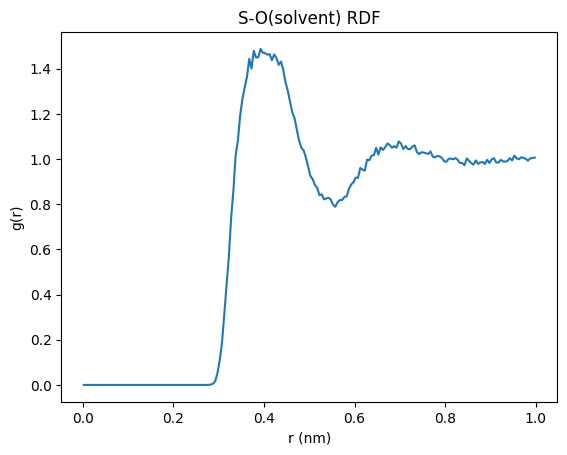

In [28]:
pairs = traj.topology.select_pairs(solute_S, solvent_O)

r, g_r = md.compute_rdf(traj, pairs=pairs, r_range=(0, 1), bin_width=0.005, periodic=True)

plt.plot(r, g_r)
plt.xlabel("r (nm)")
plt.ylabel("g(r)")
plt.title("S-O(solvent) RDF")
plt.show()


In [29]:
rho = len(solvent_O) / traj.unitcell_volumes.mean()  # number density
print("The average number of solvent (water) molecules per unit volume (number density) is:", rho, "nm^-3")

coord_number = 4 * np.pi * rho * np.trapz(g_r * r**2, r)
print("Coordination number:", coord_number)

The average number of solvent (water) molecules per unit volume (number density) is: 33.405285151823264 nm^-3
Coordination number: 136.52317308698318


/var/folders/tx/zbry1_2j2_57jk0nsqv4m9080000gn/T/ipykernel_36163/3199095728.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  coord_number = 4 * np.pi * rho * np.trapz(g_r * r**2, r)


In [30]:
traj.superpose(traj, 0)

<mdtraj.Trajectory with 10000 frames, 3003 atoms, 1001 residues, and unitcells at 0x15c0e4f10>

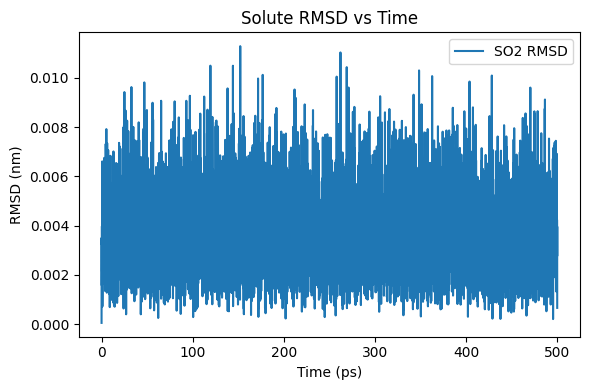

In [31]:
rmsd = md.rmsd(traj, traj, 0, atom_indices=solute)
rmsd_all = md.rmsd(traj, traj, 0)

dt_fs = 0.5      # your timestep
save_interval = 100  # frames saved every N steps
time_ps = np.arange(traj.n_frames) * dt_fs * save_interval / 1000

plt.figure(figsize=(6,4))
plt.plot(time_ps, rmsd, label="SO2 RMSD")
plt.xlabel("Time (ps)")
plt.ylabel("RMSD (nm)")
plt.title("Solute RMSD vs Time")
plt.legend()
plt.tight_layout()
plt.show()

### Solvent Leakage

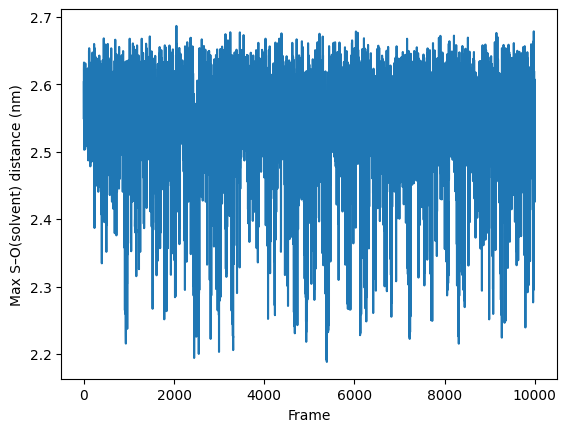

In [32]:
solute_S = top.select("not water and element S")

pairs = top.select_pairs(solute_S, solvent_O)
d = md.compute_distances(traj, pairs)  # shape (frames, waters)

max_dist_per_frame = d.max(axis=1)

plt.plot(max_dist_per_frame)
plt.xlabel("Frame")
plt.ylabel("Max S–O(solvent) distance (nm)")
plt.show()

Solute is engulfed by solvent over all frames, the droplet does not leak, and water exchange does not occur.
